# Laboratorium 10 - Warstwy Transformer


Na tym laboratorium zapoznamy się z warstwami Transformer i koncepcją hooks - funkcji, które jesteśmy w stanie "podłączyć" do istniejącego modelu na przejściowych warstwach przetwarzania.

Transformery to warstwy oparte o moduł uwagi. Koncepcja "uwagi" w sieciach głębokich to próba przetwarzania złożonych zależności w **zbiorach** obiektów - niekoniecznie sekwencjach, ale jest to jedno z typowych zastosowań.

Przykładowo, w przetwarzaniu zdania w języku naturalnym mamy problem ze złożonością naturalnej gramatyki, bo zależności niekoniecznie będą działały na zasadzie "każde słowo wpływa tylko na kolejne, następujące po nim słowo" (a wtedy nawięcej sensu miałoby działanie na zasadzie czystej rekurencji).

Zamiast tego, wykorzystanie uwagi oznacza, że przetwarzając słowo, możemy zwrócić **uwagę** na inne słowa **które są dla niego istotne**. Moduł uwagi musi się więc wyuczyć informacji o tym, które słowa są istotne dla siebie nawzajem. W najprostszej implementacji oznacza to porównywanie **każdego słowa z każdym**.

# Warstwa Transformer

Przyjrzyjmy się wewnętrznej strukturze warstwy Transformer:

In [1]:
import torch

transformer = torch.nn.Transformer(d_model=10, nhead=1)

print(transformer)

Transformer(
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=10, out_features=10, bias=True)
        )
        (linear1): Linear(in_features=10, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=10, bias=True)
        (norm1): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=10, out_featu

/home/jedkociecki/repos/studia/ai/deep-neural-network-pwr/.venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Ta implementacja podąża za oryginalną strukturą z *Attention is All You Need*, więc rozdziela enkodery i dekodery (ponieważ ta publikacja działała na problemie automatycznego tłumaczenia, gdzie potrzebna jest uwaga ze zdania wyjściowego na inne zdanie wejściowe), ma wiele dodatkowych operacji liniowych, LayerNorm, etc.

Sednem transformerów jest jednak operacja uwagi. Uwaga oparta o moduły self-attention (nazwę transformer w zasadzie mozna zastosować do dowolnych sieci opierających się o ten moduł) daje sieciom głębokim możliwość dopasowania do wielu typów danych w kórych zachodzą relacje między elementami: sekwencji (relacje w czasie), grafów (połączenia), obrazów (relacje pozycyjne w przestrzeni 2d), języka naturalnego (gramatyka) etc. Dzieje się tak, ponieważ bazowy mechanizm to po prostu porównanie każdy-z-każdym, a konkretną topologię problemu dodajemy przez inne mechanizmy, takie jak positional embedding i maskowanie.

# Zasada działania self-attention

Chcemy żeby każdy z elementów sekwencji "zapytał" (**query**) pozostałe elementy o to jak pozostałe elementy są **istotne dla niego**.

Aby to zapytanie miało sens, nasz element potrzebuje też jakiejś reprezentacji mówiącej relewantności dla innnych "pytających" elementów (**key**). W oparciu o to, możemy mnożąc macierze otrzymać macierz `liczba_elementów x liczba_elementów`. Następnie wykonamy na niej operację softmax. W ten sposób każdy element otrzymuj swoje "wagi uwagi" odnośnie wszystkich pozostałych elementów, które dzięki softmaxowi sumują się do jedynki.

Mając takie wagi, możemy zsumować reprezentacje pozostałych elementów wymnożone przez ich wagi. Ponieważ wynik tej operacji ma już iść dalej, a reprezentacje query i key służyły głównie do ustalania istotności elementów względem siebie nawzajem, stworzymy trzecią reprezentację elementów na potrzeby samego sumowania (**value**). W kodzie, dla uproszczenia bez batchowania danych:

In [2]:
sequence = torch.zeros((100,5))

query_projection = torch.nn.Linear(5,3)
key_projection = torch.nn.Linear(5,3)
value_projection = torch.nn.Linear(5,3)


q = query_projection(sequence)
k = key_projection(sequence)
v = value_projection(sequence)

attention = torch.nn.functional.softmax(q @ k.T, dim=-1)

print(attention.shape)

output = attention @ v

print(output.shape)

torch.Size([100, 100])
torch.Size([100, 3])


# Positional Embedding

O ile transformer osiągają imponujące wyniki w zadaniach sekwencyjnych, warto zwrócić uwagę, że zależności sekwencyjne nie są wbudowane w opisaną wyżej architekturę self-attention tak jak zależność, że krok n następuje po n-1 w sieciach rekurencyjnych, czy zależnoci pozycyjne w opercję konwolucji. Możemy wymusić, aby dla zadań predykcyjnych krok czasowy n nie widział króków n+1 i dalszych, ale sąsiedztwo w czasie w dalszym ciągu nie ma odzwierciedlenia w architekturze.

Istnieje bardzo proste rozwiązanie: dodajemy pozycję w sekwencji jako zmienną wejściową. Nie zawsze jest to reprezentacja dosłownie wyrażająca pozycje jako liczbę całkowitą - indeks, ale idea sprowadza się do dodania osadzenia pozycji wejściowej do naszych danych. Osadzenie można uzyskać z apomocą warstwy Mebedding, poznanej w poprzednim zadaniu.

Bardziej zaawansowane mechanizmy wykorzystują dodawanie informacji o pozycji na poziomie mechanizmu uwagi, modifikując wynik operacji mnożenia Q przez K, co pozwala uwzględnić informację o relatywnej pozycji.

## Zadanie 1

Przeprowadź trening sieci złożonej z trzech warstw TransformerEncoderLayer (w torch.nn) na zbiorach z poprzedniego zadania. Użyj jednej z opisanych wyżej wersji positional embedding. Dla klasyfikacji, dodaj osobny token na początku każdego zdania (tak aby sam w sobie nie był słowem).

In [4]:
import ssl, certifi, torch, torch.nn as nn, numpy as np, math, matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    path='imdb.npz', num_words=None, skip_top=0,
    maxlen=None, seed=113, start_char=1, oov_char=2, index_from=3
)

MAX_LEN    = 200
VOCAB_SIZE = max(max(s) for s in x_train) + 1
EMBED_DIM  = 64
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

class IMDBDataset(Dataset):
    def __init__(self, sequences, labels, max_len=None):
        self.labels = torch.tensor(labels, dtype=torch.float32)
        if max_len:
            sequences = [s[:max_len] for s in sequences]
        self.sequences = [torch.tensor(s, dtype=torch.long) for s in sequences]
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.sequences[idx], self.labels[idx]

def collate_padded(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    padded  = pad_sequence(seqs, batch_first=True, padding_value=0)
    return padded, lengths, torch.stack(labels)

train_loader = DataLoader(IMDBDataset(x_train, y_train, MAX_LEN), batch_size=64, shuffle=True,  collate_fn=collate_padded)
test_loader  = DataLoader(IMDBDataset(x_test,  y_test,  MAX_LEN), batch_size=64, shuffle=False, collate_fn=collate_padded)

x, lengths, y = next(iter(train_loader))
print(f'batch: {x.shape}, lengths: {lengths[:5]}')

I0000 00:00:1778939440.983495    3413 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


batch: torch.Size([64, 200]), lengths: tensor([130, 190, 130, 112, 144])


In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=3,
                 max_len=MAX_LEN+1, dropout=0.1):
        super().__init__()

        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))  

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embedding   = nn.Embedding(max_len, d_model)  

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier  = nn.Linear(d_model, 1)
        self.dropout     = nn.Dropout(dropout)

    def forward(self, x, lengths=None):
        batch_size, seq_len = x.shape

        # 1. Token embedding + positional embedding
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, -1)
        x = self.token_embedding(x) + self.pos_embedding(positions)
        x = self.dropout(x)

        # 2. Doklejenie CLS na początku (tak jak w notatniku)
        cls = self.cls_token.expand(batch_size, -1, -1)
        x   = torch.cat([cls, x], dim=1)  # (batch, seq_len+1, d_model)

        # 3. Maska paddingu (z notatnika)
        if lengths is not None:
            seq_len_with_cls = x.size(1)
            mask = torch.zeros(batch_size, seq_len_with_cls, dtype=torch.bool, device=x.device)
            for i, l in enumerate(lengths):
                if l + 1 < seq_len_with_cls:
                    mask[i, l+1:] = True
        else:
            mask = None

        # 4. Transformer
        out = self.transformer(x, src_key_padding_mask=mask)

        # 5. Klasyfikacja z CLS
        return self.classifier(out[:, 0, :]).squeeze(-1)

torch.Size([64])


In [ ]:
def train_transformer(model, train_loader, test_loader, epochs=10, lr=1e-3, device='cpu'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for x, lengths, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out  = model(x, lengths)
            loss = criterion(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item() * y.size(0)
            correct    += ((out > 0) == y.bool()).sum().item()
            total      += y.size(0)

        train_loss = total_loss / total
        train_acc  = correct / total

        model.eval()
        correct_t, total_t = 0, 0
        with torch.no_grad():
            for x, lengths, y in test_loader:
                x, y = x.to(device), y.to(device)
                out = model(x, lengths)
                correct_t += ((out > 0) == y.bool()).sum().item()
                total_t   += y.size(0)

        test_acc = correct_t / total_t
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        print(f"Epoch {epoch+1}/{epochs} | loss: {train_loss:.4f} | "
              f"train acc: {train_acc:.3f} | test acc: {test_acc:.3f}")

    return history


model = TransformerClassifier(
    vocab_size=VOCAB_SIZE, d_model=EMBED_DIM,
    nhead=4, num_layers=3, dropout=0.1
)

print(f'Parametrów: {sum(p.numel() for p in model.parameters()):,}')

history = train_transformer(model, train_loader, test_loader, epochs=10, device=DEVICE)
torch.save(model.state_dict(), 'transformer_imdb.pth')

Parametrów: 5,819,649


/home/jedkociecki/repos/studia/ai/deep-neural-network-pwr/.venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1/10 | loss: 0.5747 | train acc: 0.679 | test acc: 0.784
Epoch 2/10 | loss: 0.4071 | train acc: 0.813 | test acc: 0.802
Epoch 3/10 | loss: 0.3351 | train acc: 0.856 | test acc: 0.826
Epoch 4/10 | loss: 0.2811 | train acc: 0.884 | test acc: 0.843
Epoch 5/10 | loss: 0.2372 | train acc: 0.906 | test acc: 0.840
Epoch 6/10 | loss: 0.2023 | train acc: 0.922 | test acc: 0.831
Epoch 7/10 | loss: 0.1703 | train acc: 0.937 | test acc: 0.843
Epoch 8/10 | loss: 0.1434 | train acc: 0.947 | test acc: 0.834
Epoch 9/10 | loss: 0.1196 | train acc: 0.957 | test acc: 0.834
Epoch 10/10 | loss: 0.1028 | train acc: 0.965 | test acc: 0.832


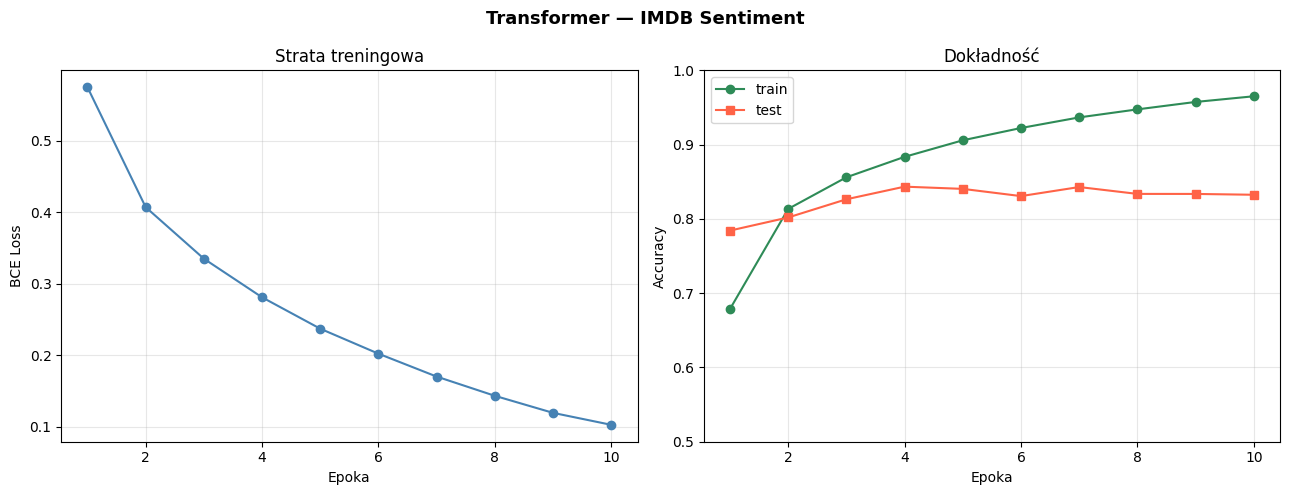

Finalna dokładność testowa: 0.832


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
xs = range(1, len(history['train_loss']) + 1)

axes[0].plot(xs, history['train_loss'], marker='o', color='steelblue')
axes[0].set_title('Strata treningowa')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('BCE Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(xs, history['train_acc'], marker='o', color='seagreen', label='train')
axes[1].plot(xs, history['test_acc'],  marker='s', color='tomato',   label='test')
axes[1].set_title('Dokładność')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Transformer — IMDB Sentiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Finalna dokładność testowa: {history['test_acc'][-1]:.3f}") 

## Pytorch hooks

Działając z głębokimi sieciami, często korzystać będziemy z gotowych modeli, a jeżeli chcielibyśmy spojrzeć na to, co dzieje się wewnątrz sieci, próba napisania od nowa własnego `forward` które weźmie to pod uwagę nie jest wygodnym rozwiązaniem.

Domyślna klasa reprezentująca warstwę w torchu, czyli `torch.nn.Module`, oferuje nam możliwość wstrzyknięcia własnego kodu zarówno w `forward`, jak i `backward` poprzez rejestrację hooków. Są to funkcje, które automatycznie wywołają się na wejściu, wyjściu lub gradiencie przy przetwarzaniu danych przez tenże moduł.

Dokładniej, dostępne są możliwości:


*   `register_forward_pre_hook` pozwala modyfikować dane przed wywołaniem `forward` modułu, można ustawić flagę `with_kwargs=True` żeby modyfikować też paramtery nazwane (przyda się w zadaniu 2).

      Funkcja podana jako hook powinna mieć format:

      `hook(module, args) -> None or modified_input`

      lub jeśli `use_kwargs=True`

      `hook(module, args, kwargs) -> None or (modified_input, kwargs)`

*   `register_forward_hook` pozwala nam zmodyfikować wyjście po `forward`, analogicznie można ustawić `with_kwargs=True` aby podejrzeć parametry nazwane, ale nie aby je zmodyfikować

*   `register_full_backward_hook` oraz `register_full_backward_pre_hook` w analogiczny sposób dają nam dostęp do gradientu po wyjściach/wejściach do modułu przy wywołaniu `backward`

Po wykorzystaniu hooks, jeżeli chcemy je usunąć przed dalszym korzystaniem z modelu, możemy skorzystać z obiektu `RemovableHandle` zwracanego przez powyższe funkcje.

In [9]:
linear = torch.nn.Linear(5,1)

data_batch = torch.zeros((10,5))
data_batch.requires_grad = True


def input_modifying_hook(module, input):
  print('pre-hook print:\n', input)
  return input[0] + 1

def output_modifying_hook(module, input, output):
  print('forward hook print:\n', input)
  return output + 1


def gradient_printing_hook(module, grad_input, grad_output):
  print('gradient hook print:\n', grad_input)
  return None

def not_firing_hook(module, grad_input, grad_output):
  print('THIS WILL NOT BE PRINTED')
  return None


# na wejściu podajemy zera, więc wyjście powinno być rónwe biasowi
print('layer bias:\n', linear.bias)
print('output without hooks:\n', linear(data_batch))

# po modyfikacji wejścia, wyjście powinno się zmienić
handle = linear.register_forward_pre_hook(input_modifying_hook)
print('output with pre-hook:\n', linear(data_batch))
handle.remove()

# po modyfikacji wyjścia, wyjście powinno się zmienić dokładnie o 1
handle = linear.register_forward_hook(output_modifying_hook)
print('output with forward hook:\n', linear(data_batch))
handle.remove()


handle = linear.register_full_backward_hook(gradient_printing_hook)
out = linear(data_batch).sum()
handle2 = linear.register_full_backward_hook(not_firing_hook)
# obie funkcje są rejestrowane jako backward hook, ale wywoła się tylko gradient_printing_hook
# dlaczego? ponieważ zarejestrowaliśmy not_firing_hook już PO zbudowaniu grafu obliczeniowego
out.backward()

layer bias:
 Parameter containing:
tensor([-0.3163], requires_grad=True)
output without hooks:
 tensor([[-0.3163],
        [-0.3163],
        [-0.3163],
        [-0.3163],
        [-0.3163],
        [-0.3163],
        [-0.3163],
        [-0.3163],
        [-0.3163],
        [-0.3163]], grad_fn=<AddmmBackward0>)
pre-hook print:
 (tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]], requires_grad=True),)
output with pre-hook:
 tensor([[0.3027],
        [0.3027],
        [0.3027],
        [0.3027],
        [0.3027],
        [0.3027],
        [0.3027],
        [0.3027],
        [0.3027],
        [0.3027]], grad_fn=<AddmmBackward0>)
forward hook print:
 (tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
    

**UWAGA**: wykonywanie hooków może dodać znaczący narzut obliczeniowy, zwłaszcza na karcie graficznej gdzie może wymusić dodatkowe synchronizacje rdzeni. To narzędzie do debuggingu i inspekcji wytrenowanych modeli, nie do wydajnej implementacji nowych funkcjonalności.

# Uwaga a wyjaśnialność

Mechanizm uwagi daje nam jeden z najprostszych mechanizmów interpretowalności modeli - wglądu w oparciu o co nasz black-box podejmuje decyzje. Podglądając wagi uwagi możemy zobaczyć, jak istotne są słowa relatywnie do siebie nawzajem, a patrząc na uwagę w pozycji którą wykorzystujemy do klasyfikacji - na to jak istotne ogólnie są tokeny dla klasyfikatora.

Wyjaśnialność tego typu nazywamy atrybucją i odpowiada ona na pytanie, które wejście jest istotne dla decyzji/wyjścia modelu. Alternatywna intuicja, molzliwa do zastosowania do szerszej puli modeli, to wyjaśnialność oparta o gradient. Założeniem tutaj jest, że jeżeli wyliczymy gradient z wyjścia po wejściu, to będzie on wysoki dla tych wejść które były istotne.

Oba te podejścia można łatwo zaimplementować, korzystając z funkcjonalności forward i backward hooks.

# Zadanie 2

Podepnij do wyuczonego przez siebie modelu hooki, które pozwolą uzyskać inofrmacje o "istotności" wejściowych tokenów dla wyjścia. Istotność n-tego tokenu będzie to odpowiednio: waga uwagi tokenu klasyfikacji na n-tym tokenie lub suma gradientów z wyjścia modelu po wejściu na n-tym tokenie. (Wynikiem w obu przypadkach powinien być tensor gdzie każdemu tokenowi wejściowemu odpowiada jedna wartość "istotności".)  

Zdefiniuj swoje funkcje tak, aby łatwo dało się uzyskać dla wybranego zdania ze zbioru wejściowego istotność na wybranym poziomie sieci (jednej z trzech warstw). Wagi uwagi dostępne będą w module self-attention zadanej warstwy, gradient powinien być wyliczany po wejściu do całej warstwy TransformerEncoderLayer.

Zwizualizuj istotność wejść na podstawie przykładowych zdań ze zbioru IMDB. Spróbuj dobrać zdania, w których będzie widać zarówno podobieństwa, jak i różnice w wyjaśnieniu opartym o gradient vs. o uwagę.

In [10]:
word_idx    = imdb.get_word_index(path='imdb_word_index.json')
idx_to_word = {v + 3: k for k, v in word_idx.items()}
idx_to_word[0] = '<PAD>'
idx_to_word[1] = '<START>'
idx_to_word[2] = '<OOV>'

def find_example(keyword, label):
    """Znajdź pierwsze zdanie testowe zawierające dane słowo i label (0/1)."""
    kid = word_idx.get(keyword, -1) + 3
    for seq, lbl in zip(x_test, y_test):
        if lbl == label and kid in seq:
            return seq
    return None

# Jedno zdanie pozytywne i jedno negatywne
pos_seq = find_example('brilliant', label=1)
neg_seq = find_example('boring',    label=0)

# Podgląd pierwszych słów
print('POZYTYWNE:', [idx_to_word.get(i, '?') for i in pos_seq[:15]])
print('NEGATYWNE:', [idx_to_word.get(i, '?') for i in neg_seq[:15]])

POZYTYWNE: ['<START>', 'this', 'film', 'requires', 'a', 'lot', 'of', 'patience', 'because', 'it', 'focuses', 'on', 'mood', 'and', 'character']
NEGATYWNE: ['<START>', 'the', "emperor's", 'richard', 'haydn', 'dog', 'is', 'betrothed', 'to', "johanna's", 'joan', 'fontaine', 'dog', 'however', 'when']


In [26]:
def analyze_sentence(model, sequence, layer_idx=0, max_words=25, device='cpu'):
    model.eval()
    seq_cut = sequence[:max_words]
    # seq_cut = sequence
    tokens  = [idx_to_word.get(i, '?') for i in seq_cut]

    x = torch.tensor([seq_cut], dtype=torch.long, device=device)

    captured = {'attn': None, 'grad': None}

    def attn_hook(module, input, output):
        captured['attn'] = output[1].detach().cpu()

    def grad_hook(module, grad_input, grad_output):
        if grad_input[0] is not None:
            captured['grad'] = grad_input[0].detach().cpu()

    target_layer = model.transformer.layers[layer_idx]

    # need_weights=True + average_attn_weights=True wymusza zwrócenie wag
    original_forward = target_layer.self_attn.forward
    def patched_forward(*args, **kwargs):
        kwargs['need_weights']        = True
        kwargs['average_attn_weights'] = True
        return original_forward(*args, **kwargs)
    target_layer.self_attn.forward = patched_forward

    h1 = target_layer.self_attn.register_forward_hook(attn_hook)
    h2 = target_layer.register_full_backward_hook(grad_hook)

    out = model(x)
    out.sum().backward()

    # Przywracamy oryginalny forward
    target_layer.self_attn.forward = original_forward
    h1.remove()
    h2.remove()

    attn_scores = captured['attn'][0, 0, 1:len(seq_cut)+1]

    grad = captured['grad'][0, 1:len(seq_cut)+1]
    grad_scores = grad.norm(dim=-1)
    grad_scores = grad_scores / (grad_scores.max() + 1e-8)

    return tokens, attn_scores, grad_scores

In [28]:
def find_example(keyword, label, within=15):
    kid = word_idx.get(keyword, -1) + 3
    for seq, lbl in zip(x_test, y_test):
        if lbl == label and kid in seq[:within]:
            return seq
    return None

pos_seq = find_example('brilliant', label=1)
neg_seq = find_example('boring',    label=0)

print('POZYTYWNE:', [idx_to_word.get(i, '?') for i in pos_seq[:15]])
print('NEGATYWNE:', [idx_to_word.get(i, '?') for i in neg_seq[:15]])

POZYTYWNE: ['<START>', 'quai', 'des', 'directed', 'by', 'the', 'brilliant', 'henri', 'georges', 'clouzot', 'is', 'a', 'film', 'to', 'treasure']
NEGATYWNE: ['<START>', 'this', 'documentary', 'was', 'boring', 'and', 'quite', 'stupid', 'br', 'br', 'i', 'mean', 'the', 'documentary', 'maker']


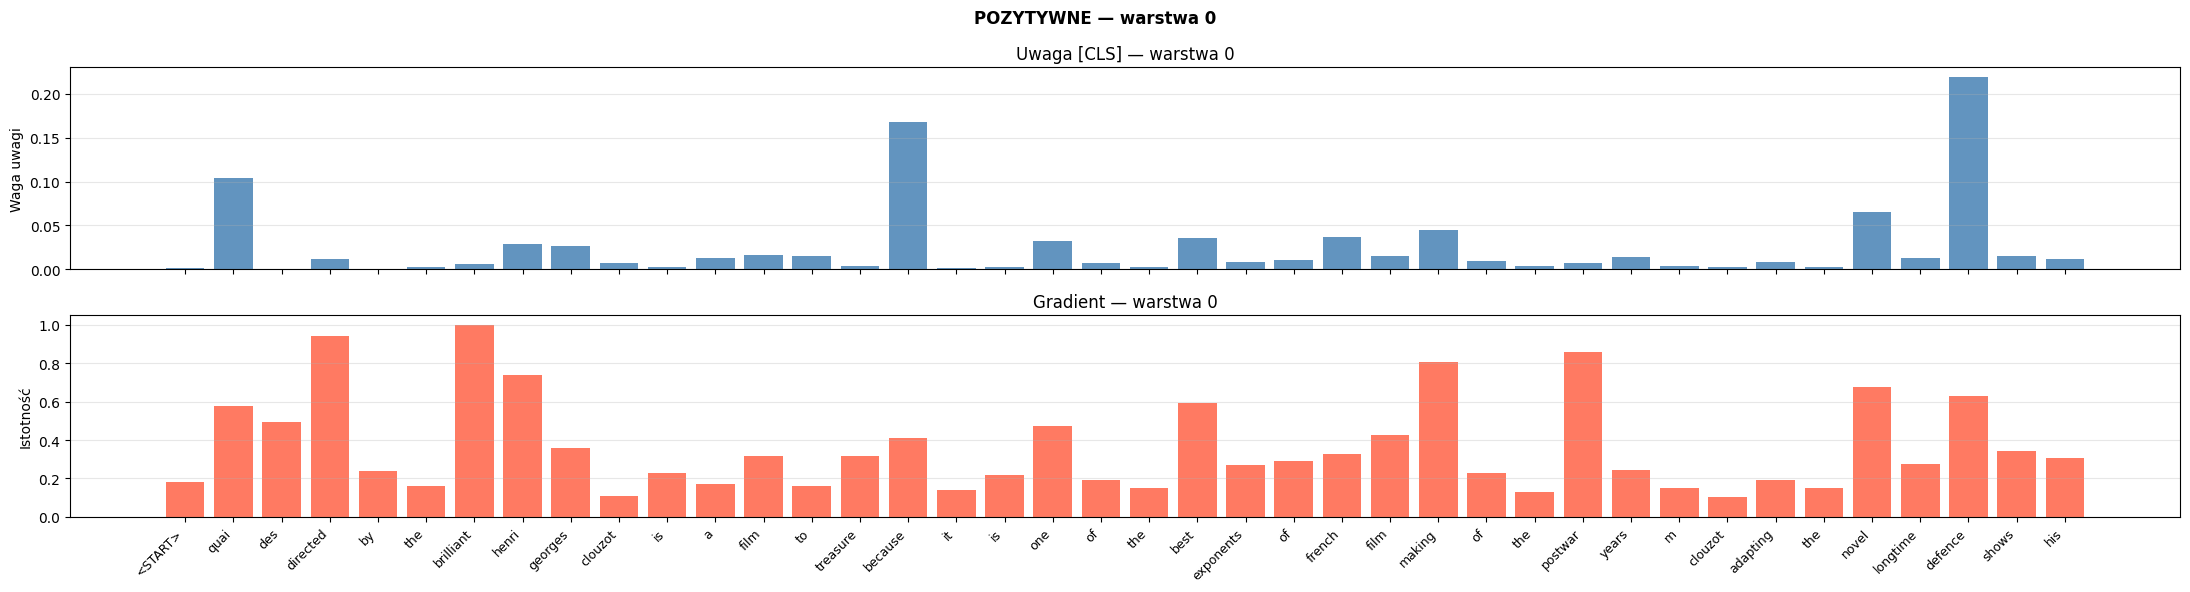

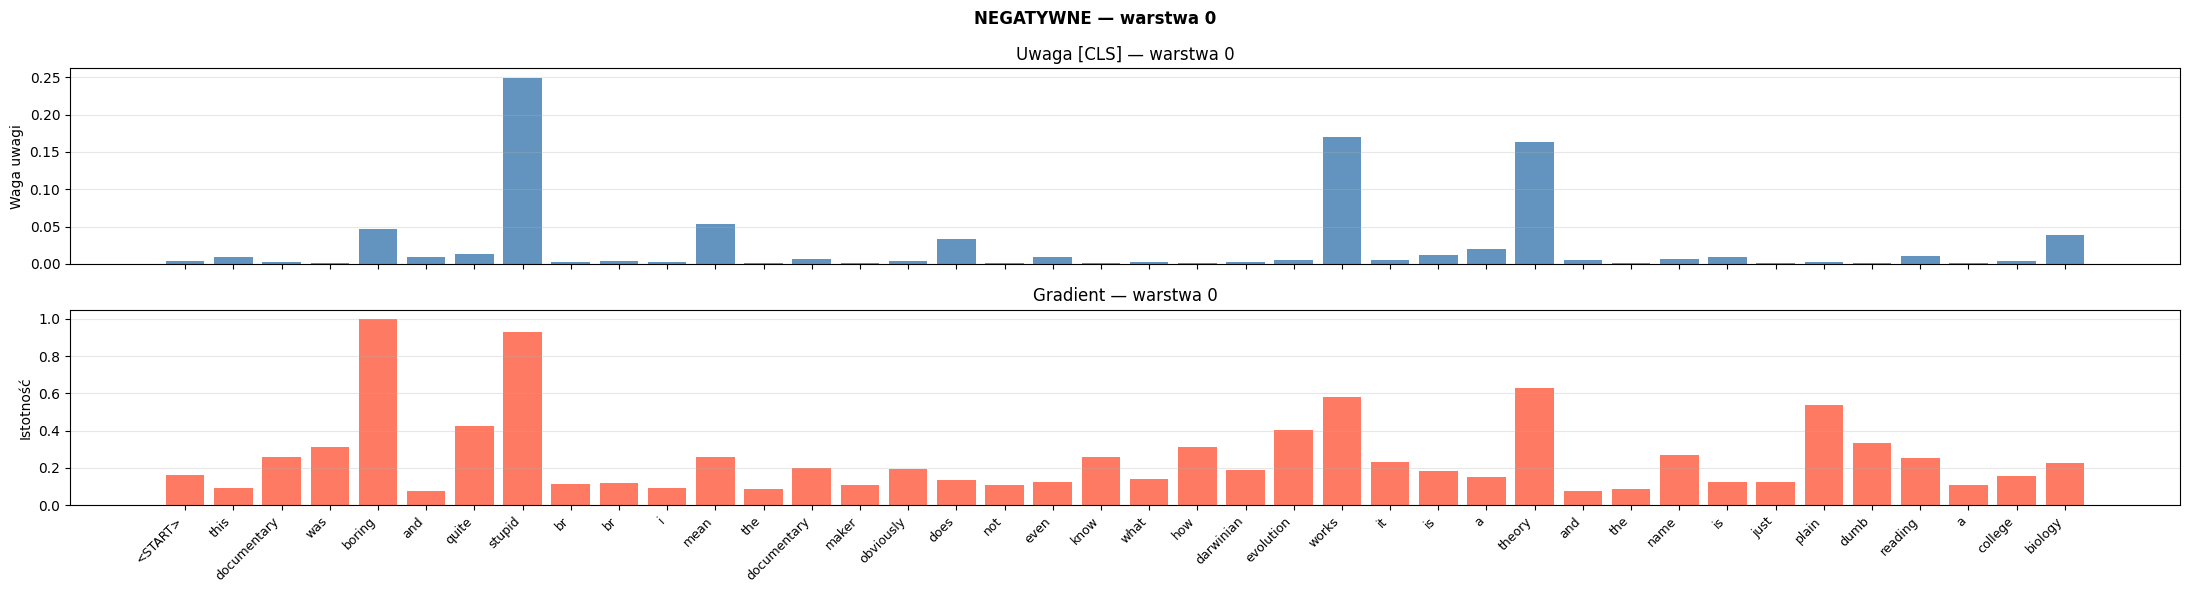

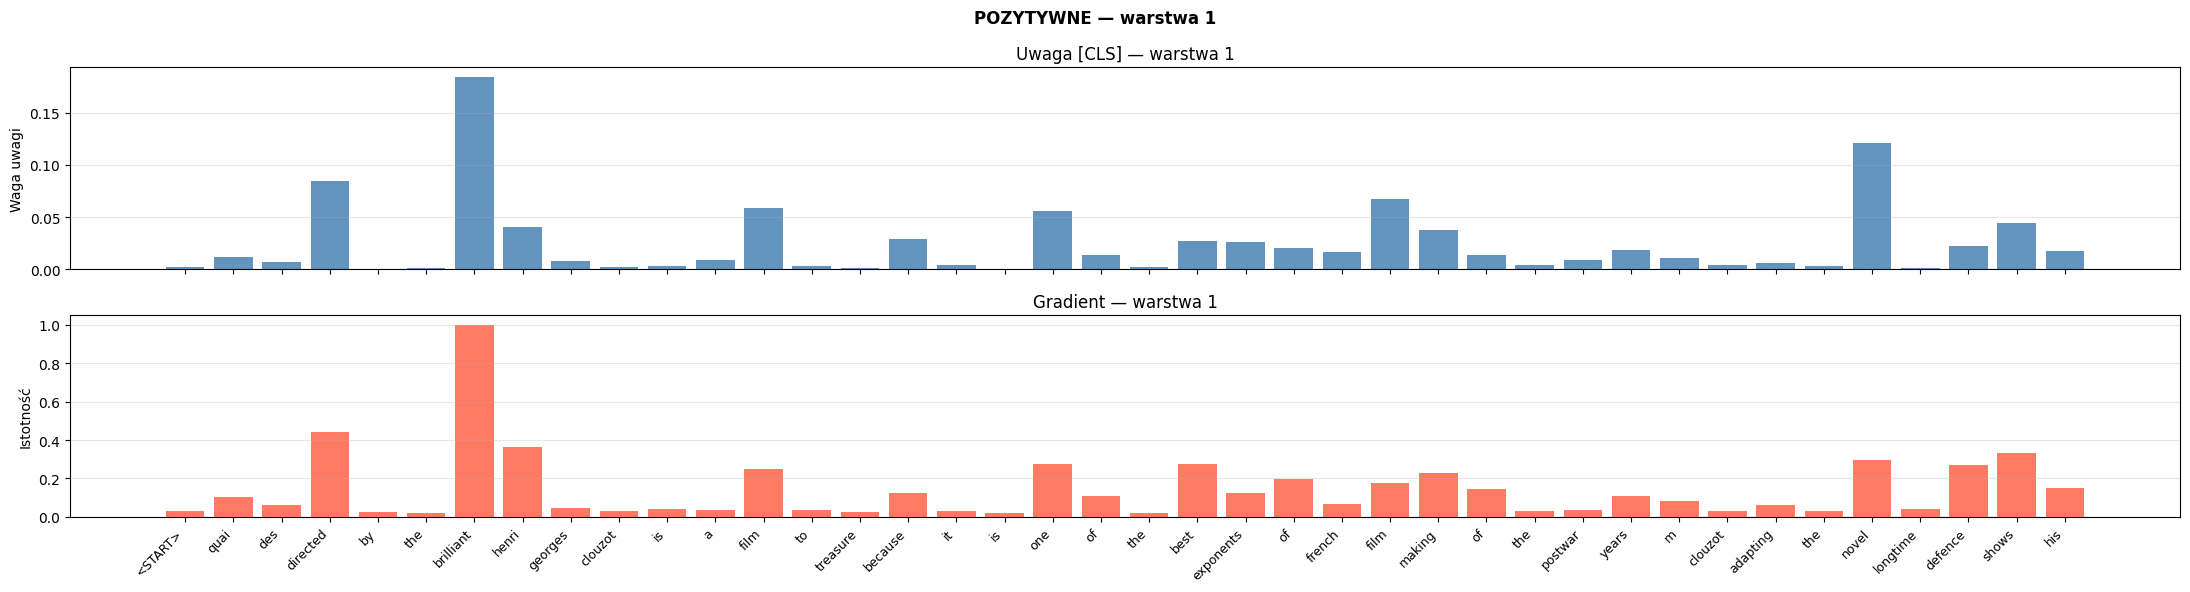

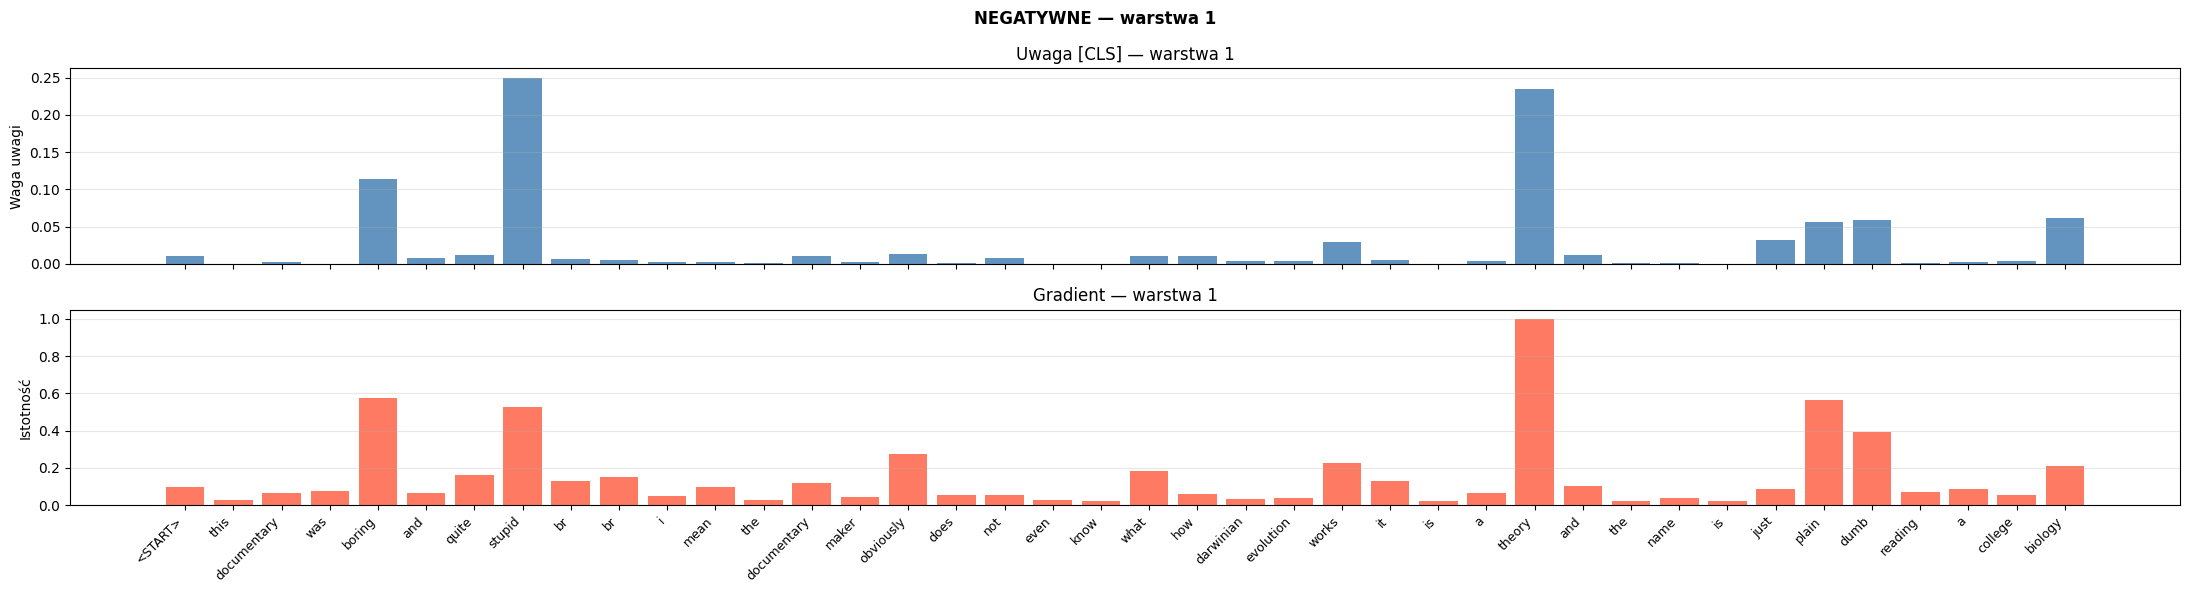

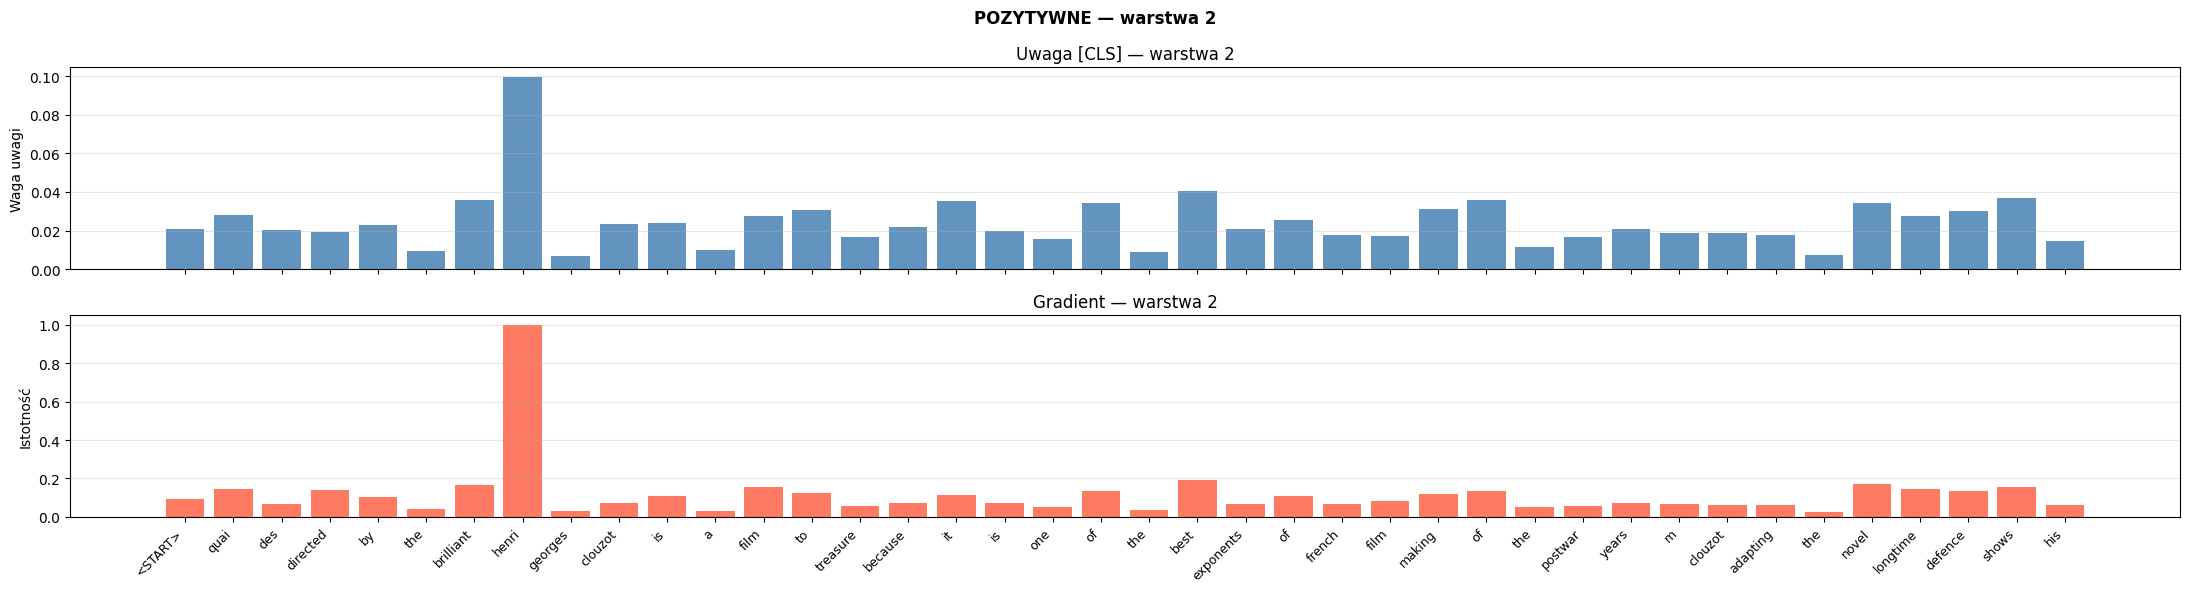

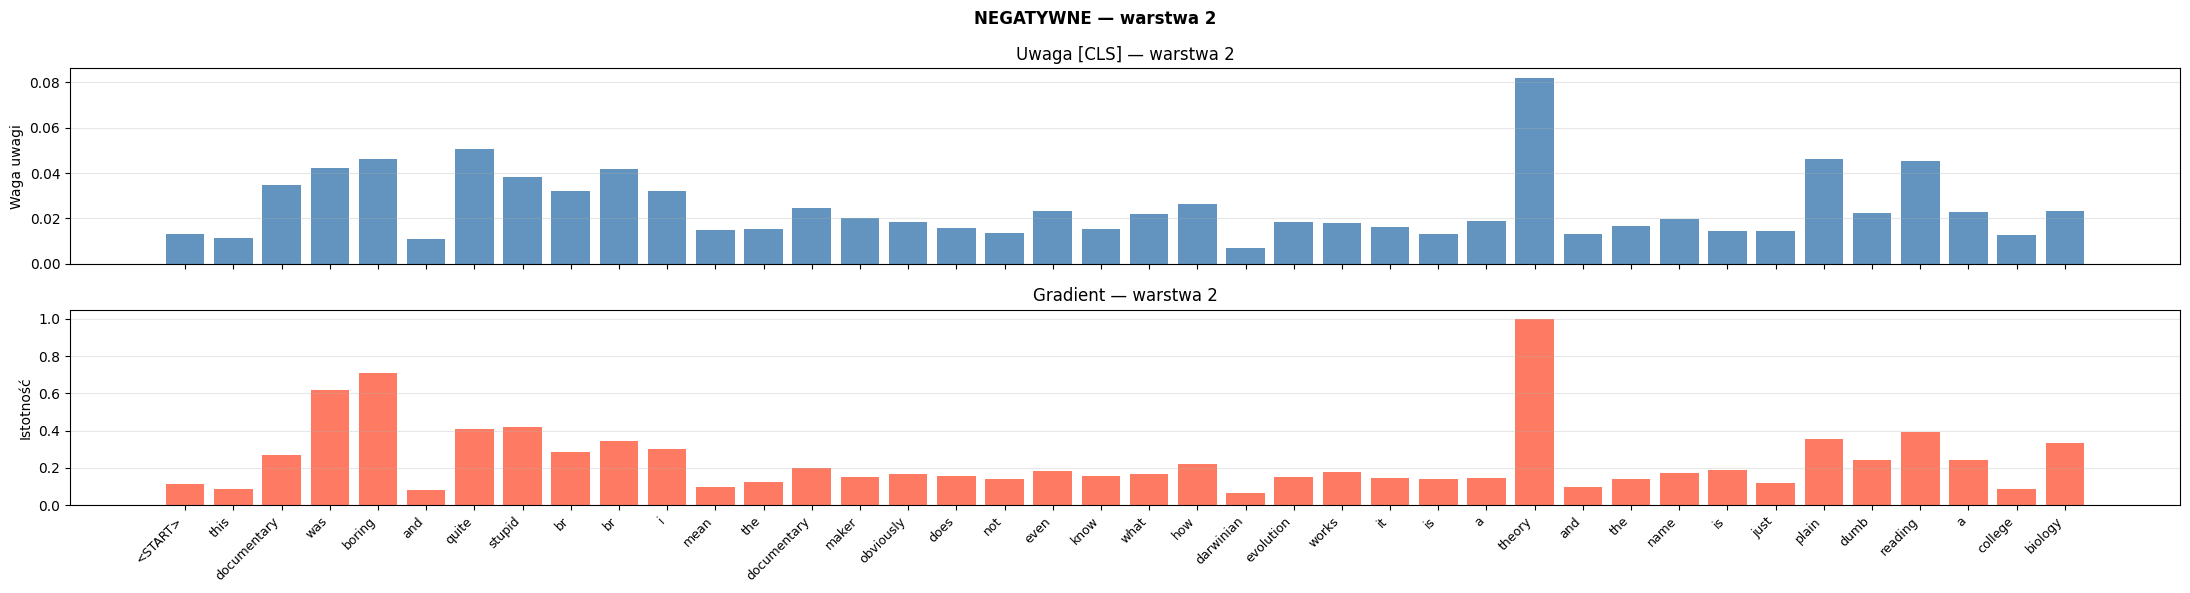

In [30]:
def plot_importance(tokens, attn_scores, grad_scores, title='', layer_idx=0):
    n       = len(tokens)
    x       = np.arange(n)
    attn_np = attn_scores.detach().numpy()
    grad_np = grad_scores.detach().numpy()

    fig, axes = plt.subplots(2, 1, figsize=(max(12, n * 0.55), 6), sharex=True)

    axes[0].bar(x, attn_np, color='steelblue', alpha=0.85)
    axes[0].set_title(f'Uwaga [CLS] — warstwa {layer_idx}')
    axes[0].set_ylabel('Waga uwagi')
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].bar(x, grad_np, color='tomato', alpha=0.85)
    axes[1].set_title(f'Gradient — warstwa {layer_idx}')
    axes[1].set_ylabel('Istotność')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(tokens, rotation=45, ha='right', fontsize=9)
    axes[1].grid(axis='y', alpha=0.3)

    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Wizualizacja dla wszystkich 3 warstw, obu zdań
for layer_idx in [0, 1, 2]:
    tokens, attn, grad = analyze_sentence(model, pos_seq, max_words=40, layer_idx=layer_idx, device=DEVICE)
    plot_importance(tokens, attn, grad, title=f'POZYTYWNE — warstwa {layer_idx}', layer_idx=layer_idx)

    tokens, attn, grad = analyze_sentence(model, neg_seq, max_words=40, layer_idx=layer_idx, device=DEVICE)
    plot_importance(tokens, attn, grad, title=f'NEGATYWNE — warstwa {layer_idx}', layer_idx=layer_idx)
